# ForceSMIP Challenge Analysis - Refactored

This notebook demonstrates the ForceSMIP analysis using the new encapsulated modules.

## 1. Setup and Imports

In [80]:
import sys
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

# Add src to path
sys.path.append(os.path.join(os.getcwd(), "ForceSMIP"))

# Import our modules
from data_loader import ForceSMIPDataLoader, yearly_average, compute_yearly_average_dict
from preprocessing import (
    merge_training_data, reshape_training_data, 
    apply_notnan_filter_complete
)
from algorithms import WeightedRidgeRegression, ridge_regression, LowRankSolver
from evaluation import ForceSMIPEvaluator, compute_trends_from_data, compute_statistics
from visualization import ForceSMIPVisualizer
from forcesmip_pipeline import ForceSMIPPipeline

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Modules loaded successfully!")

Modules loaded successfully!


## 2. Quick Start - Complete Pipeline

In [81]:
# Initialize pipeline
base_path = '/net/krypton/climdyn_nobackup/FTP'
variable = 'tos'  # Precipitation

pipeline = ForceSMIPPipeline(base_path, variable=variable)
print(f"Pipeline initialized for variable: {variable}")

Pipeline initialized for variable: tos


In [82]:
# # Run complete analysis with default parameters
# summary = pipeline.run_complete_analysis(
#     lambda_reg=2500.0,     # Ridge regression regularization
#     rank=10,               # Low-rank approximation rank
#     apply_smoothing=False  # Whether to apply temporal smoothing
# )

# print("\n=== Analysis Complete! ===")

In [83]:
# # Display performance summary
# print("\n=== Performance Summary ===")
# for method, metrics in summary.items():
#     print(f"\n{method}:")
#     print(f"  Mean NRMSE: {metrics['mean_nrmse']:.4f}")
#     print(f"  Mean Pattern Correlation: {metrics['mean_pattern_corr']:.4f}")
#     print(f"  Worst NRMSE: {metrics['worst_nrmse']:.4f}")

## 3. Step-by-Step Analysis (Manual Pipeline)

### 3.1 Data Loading

In [84]:
# Initialize data loader
data_loader = ForceSMIPDataLoader(base_path)

# Load training data
print("Loading training data...")
dic_data, dic_forced_response, longitude, latitude = data_loader.load_training_data(variable)

print(f"Training data loaded:")
print(f"  Number of models: {len(dic_data)}")
print(f"  Model names: {list(dic_data.keys())}")
print(f"  Grid shape: {latitude.shape[0]} x {longitude.shape[0]}")
print(f"  Time steps: {list(dic_data.values())[0].shape[1]}")

Loading training data...
Processing 1/5: CESM2
  Processing 1/50: tos_mon_CESM2_historical_ssp370_r1251.013i1p1f1.188001-210012.nc


/home/vcohen/.conda/envs/cope/lib/python3.9/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


  Processing 2/50: tos_mon_CESM2_historical_ssp370_r1011.001i1p1f1.188001-210012.nc
  Processing 3/50: tos_mon_CESM2_historical_ssp370_r1251.015i1p1f1.188001-210012.nc
  Processing 4/50: tos_mon_CESM2_historical_ssp370_r1031.002i1p1f1.188001-210012.nc
  Processing 5/50: tos_mon_CESM2_historical_ssp370_r1251.014i1p1f1.188001-210012.nc
  Processing 6/50: tos_mon_CESM2_historical_ssp370_r1051.003i1p1f1.188001-210012.nc
  Processing 7/50: tos_mon_CESM2_historical_ssp370_r1251.016i1p1f1.188001-210012.nc
  Processing 8/50: tos_mon_CESM2_historical_ssp370_r1071.004i1p1f1.188001-210012.nc
  Processing 9/50: tos_mon_CESM2_historical_ssp370_r1251.017i1p1f1.188001-210012.nc
  Processing 10/50: tos_mon_CESM2_historical_ssp370_r1091.005i1p1f1.188001-210012.nc
  Processing 11/50: tos_mon_CESM2_historical_ssp370_r1251.018i1p1f1.188001-210012.nc
  Processing 12/50: tos_mon_CESM2_historical_ssp370_r1111.006i1p1f1.188001-210012.nc
  Processing 13/50: tos_mon_CESM2_historical_ssp370_r1251.019i1p1f1.18800

In [85]:
# Load test data
test_models = ['B', 'D', 'E', 'G', 'J']
print("\nLoading test data...")
data_test = data_loader.load_test_data(variable, test_models)
data_ground_truth = data_loader.load_ground_truth(variable, test_models)
data_estimates = data_loader.load_estimates(variable, test_models)

print(f"Test data shape: {data_test.shape}")
print(f"Ground truth shape: {data_ground_truth.shape}")
print(f"Estimates shape: {data_estimates.shape}")


Loading test data...
Loading test data for D at index 1
Loading test data for G at index 3
Loading test data for B at index 0
Loading test data for J at index 4
Loading test data for E at index 2
Loading ground truth for B at index 0
Loading ground truth for D at index 1
Loading ground truth for E at index 2
Loading ground truth for G at index 3
Loading ground truth for J at index 4
Centering data for method 8


/home/vcohen/cope/ForceSMIP/data_loader.py:210: RuntimeWarning: Mean of empty slice
  monthly_mean = np.nanmean(data_estimates[idx_m, :, month_mask, :, :], axis=0)


Centering data for method 9
Centering data for method 14
Centering data for method 24
Test data shape: (5, 876, 72, 144)
Ground truth shape: (5, 876, 72, 144)
Estimates shape: (30, 5, 876, 72, 144)


### 3.2 Data Preprocessing

In [86]:
# Compute yearly averages
print("Computing yearly averages...")
dic_data_yearly = compute_yearly_average_dict(dic_data)
dic_forced_response_yearly = compute_yearly_average_dict(dic_forced_response)

data_test_yearly = yearly_average(data_test)
data_ground_truth_yearly = yearly_average(data_ground_truth)

print(f"Yearly data shape (first model): {list(dic_data_yearly.values())[0].shape}")
print(f"Test yearly shape: {data_test_yearly.shape}")

Computing yearly averages...
Yearly data shape (first model): (50, 221, 72, 144)
Test yearly shape: (5, 73, 72, 144)


In [87]:
# Prepare training data for machine learning
print("Preparing training data...")

# Method 1: Merge all training data
x_train_merged, y_train_merged = merge_training_data(
    dic_data_yearly, dic_forced_response_yearly
)

# Method 2: Keep model separation
x_train_dict, y_train_dict = reshape_training_data(
    dic_data_yearly, dic_forced_response_yearly
)

print(f"Merged training data shape: X={x_train_merged.shape}, Y={y_train_merged.shape}")
print(f"Separated training data: {len(x_train_dict)} models")

Preparing training data...
Merged training data shape: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Separated training data: 5 models


### 3.3 Data Smoothing (Optional)

In [88]:
def capture_nans(x_train_dict):
    """
    Capture indices of NaN values across all training data.
    Args:
        x_train_dict (dict): Dictionary of training data tensors with keys as model names.
    Returns:
        nan_union (list): List of indices where NaN values are found across all models.
        notnan_inter (list): List of indices where no NaN values are found across all models.
    """
    
    # enumerate in the dictionary and get the union of the nans for each pair ((key, value))
    for (key, value) in x_train_dict.items():
        nan_indices = list(torch.where(torch.abs(value[0,0,:]) > 1e9)[0].numpy())
        if 'nan_union' not in locals():
            nan_union = nan_indices
        else:
            nan_union = list(set(nan_union) | set(nan_indices))

    notnan_inter = list(set(range(value.shape[2])) - set(nan_union))

    return nan_union, notnan_inter

In [89]:
nan_idx, notnan_idx =capture_nans(x_train_dict)

# Prepare test data for smoothing experiments
x_test = torch.from_numpy(data_test.reshape(
    data_test.shape[0], data_test.shape[1], -1
)).to(torch.float32)

print(f"Test data shape for smoothing: {x_test.shape}")

Test data shape for smoothing: torch.Size([5, 876, 10368])


In [90]:
# add the nans that are also included in the test data
# record nan indices as the union of nans on each map
nan_idx_test = nan_idx.copy()

for idx_r in range(x_test.shape[0]):

    nan_idx_test = list(set(nan_idx_test) | set(list(np.where(x_test[idx_r,0,:] < -1e10 )[0])))    
    # define not nan indices (useful to ease the computations)
notnan_idx_test = list(set(list(range(x_test.shape[2]))) - set(nan_idx_test))


# replace the nan index by Nans
notnan_idx = notnan_idx_test
nan_idx = nan_idx_test

In [91]:
# Apply not-NaN filter to all data
x_train_merged_filtered, y_train_merged_filtered, \
x_train_dict_filtered, y_train_dict_filtered, x_test_filtered = apply_notnan_filter_complete(
    x_train_merged, y_train_merged,
    x_train_dict, y_train_dict,
    x_test, notnan_idx
)

              APPLYING NOT-NAN FILTER TO ALL DATA
Valid indices count: 6837

1. Filtering merged training data...
   X: torch.Size([40885, 10368]) -> torch.Size([40885, 6837])
   Y: torch.Size([40885, 10368]) -> torch.Size([40885, 6837])

2. Filtering training dictionaries...
Filtering training dictionaries...
Keeping 6837 valid spatial features
CESM2: X torch.Size([50, 221, 10368]) -> torch.Size([50, 221, 6837])
CanESM5: X torch.Size([25, 221, 10368]) -> torch.Size([25, 221, 6837])
MIROC-ES2L: X torch.Size([30, 221, 10368]) -> torch.Size([30, 221, 6837])
MIROC6: X torch.Size([50, 221, 10368]) -> torch.Size([50, 221, 6837])
MPI-ESM1-2-LR: X torch.Size([30, 221, 10368]) -> torch.Size([30, 221, 6837])

3. Filtering test data...
   Test: torch.Size([5, 876, 10368]) -> torch.Size([5, 876, 6837])

=== FILTERING SUMMARY ===
Original spatial features: 10368
Filtered spatial features: 6837
Features removed: 3531
Reduction: 34.1%


### 3.4 Model Training

In [92]:
# Updated cell for model training
# Train global ridge regression model
lambda_reg = 500.0
print(f"Training ridge regression with lambda={lambda_reg}...")

w_ridge = ridge_regression(x_train_merged_filtered,y_train_merged_filtered, lambda_reg, verbose=True)
print(f"Ridge weights shape: {w_ridge.shape}")

# Setup low-rank solver for efficient multiple rank solutions
print(f"\nSetting up low-rank solver...")
lr_solver = LowRankSolver()
lr_solver.fit(x_train_merged_filtered, y_train_merged_filtered, w_ridge, verbose=True)

# Get solutions for multiple ranks efficiently
ranks_to_test = [5, 10, 15, 20, 25, 30]
rank_solutions = lr_solver.get_multiple_ranks(ranks_to_test, verbose=True)

# Print explained variance for different ranks
print(f"\nExplained variance by rank:")
cumulative_var = lr_solver.cumulative_variance_ratio()
for rank in ranks_to_test:
    if rank <= len(cumulative_var):
        print(f"  Rank {rank}: {cumulative_var[rank-1]:.4f}")

# Use the primary rank solution
primary_rank = 10
w_ridge_lr = rank_solutions[primary_rank]
print(f"Primary rank-{primary_rank} weights shape: {w_ridge_lr.shape}")

Training ridge regression with lambda=500.0...
Solving ridge regression with λ=500.0
Input shape: X=torch.Size([40885, 6837]), Y=torch.Size([40885, 6837])
Reshaped: X=torch.Size([40885, 6837]), Y=torch.Size([40885, 6837])
Ridge weights computed: torch.Size([6837, 6837])
Ridge weights shape: torch.Size([6837, 6837])

Setting up low-rank solver...
Computing SVD for low-rank approximations...
SVD computed: U=torch.Size([47722, 6837]), S=torch.Size([6837]), Vt=torch.Size([6837, 6837])
Singular values range: 0.000002 to 2895.492920
Computed solutions for ranks: [5, 10, 15, 20, 25, 30]

Explained variance by rank:
  Rank 5: 0.9940
  Rank 10: 0.9990
  Rank 15: 0.9997
  Rank 20: 0.9999
  Rank 25: 0.9999
  Rank 30: 0.9999
Primary rank-10 weights shape: torch.Size([6837, 6837])


In [93]:
rank_solutions[5].shape

torch.Size([6837, 6837])

In [94]:
# Train weighted ridge regression model
print(f"\nTraining weighted ridge regression with lambda={lambda_reg}...")

# Initialize weighted ridge regression
weighted_ridge = WeightedRidgeRegression()

# Train per-model weighted regression with efficient low-rank
performance = weighted_ridge.train_per_model(
    x_train_dict_filtered, y_train_dict_filtered, lambda_reg, primary_rank, verbose=True
)

# Get multiple rank solutions for weighted models
print("Computing multiple rank solutions for weighted models...")
weighted_rank_solutions = weighted_ridge.get_rank_solutions(ranks_to_test, verbose=True)

# Compute model weights for different ranks
model_weights = {}
for rank in ranks_to_test:
    model_weights[f'rank_{rank}'] = weighted_ridge.compute_weights(
        x_train_dict_filtered, y_train_dict_filtered, use_low_rank=True, rank=rank
    )

# Also compute full model weights
model_weights['full'] = weighted_ridge.compute_weights(
    x_train_dict_filtered, y_train_dict_filtered, use_low_rank=False
)

print(f"Training complete! Performance summary:")
for model_name, perf in performance.items():
    print(f"  {model_name}: MSE_full={perf['mse_full']:.6f}, MSE_rank_{primary_rank}={perf['mse_low_rank']:.6f}")

print(f"Model weights computed for ranks: {list(model_weights.keys())}")


Training weighted ridge regression with lambda=500.0...

Training model: CESM2
Solving ridge regression with λ=500.0
Input shape: X=torch.Size([11050, 6837]), Y=torch.Size([11050, 6837])
Reshaped: X=torch.Size([11050, 6837]), Y=torch.Size([11050, 6837])
Ridge weights computed: torch.Size([6837, 6837])
Computing SVD for low-rank approximations...
SVD computed: U=torch.Size([17887, 6837]), S=torch.Size([6837]), Vt=torch.Size([6837, 6837])
Singular values range: 0.000009 to 1159.157227
Computing rank-10 approximation...
Rank-10 solution computed: torch.Size([6837, 6837])
  Full MSE: 0.000149
  Rank-10 MSE: 0.000150
  Explained variance: 1.0000

Training model: CanESM5
Solving ridge regression with λ=500.0
Input shape: X=torch.Size([5525, 6837]), Y=torch.Size([5525, 6837])
Reshaped: X=torch.Size([5525, 6837]), Y=torch.Size([5525, 6837])
Ridge weights computed: torch.Size([6837, 6837])
Computing SVD for low-rank approximations...
SVD computed: U=torch.Size([12362, 6837]), S=torch.Size([683

  Full MSE: 0.000466
  Rank-10 MSE: 0.000483
  Explained variance: 0.9999

Training model: MIROC-ES2L
Solving ridge regression with λ=500.0
Input shape: X=torch.Size([6630, 6837]), Y=torch.Size([6630, 6837])
Reshaped: X=torch.Size([6630, 6837]), Y=torch.Size([6630, 6837])
Ridge weights computed: torch.Size([6837, 6837])
Computing SVD for low-rank approximations...
SVD computed: U=torch.Size([13467, 6837]), S=torch.Size([6837]), Vt=torch.Size([6837, 6837])
Singular values range: 0.000006 to 801.348450
Computing rank-10 approximation...
Rank-10 solution computed: torch.Size([6837, 6837])
  Full MSE: 0.000284
  Rank-10 MSE: 0.000291
  Explained variance: 0.9998

Training model: MIROC6
Solving ridge regression with λ=500.0
Input shape: X=torch.Size([11050, 6837]), Y=torch.Size([11050, 6837])
Reshaped: X=torch.Size([11050, 6837]), Y=torch.Size([11050, 6837])
Ridge weights computed: torch.Size([6837, 6837])
Computing SVD for low-rank approximations...
SVD computed: U=torch.Size([17887, 6837]

### 3.5 Predictions

In [95]:
# Make predictions using different methods
print("Making predictions...")

# Global models
y_pred_ridge = x_test_filtered @ w_ridge
y_pred_ridge_lr = x_test_filtered @ w_ridge_lr

# Weighted predictions
y_pred_weighted = weighted_ridge.predict_weighted(
    x_test_filtered, model_weights['full'], use_low_rank=False
)
y_pred_weighted_lr = weighted_ridge.predict_weighted(
    x_test_filtered, model_weights['rank_10'], use_low_rank=True
)


print(f"Predictions shape: {y_pred_ridge.shape}")
print("Prediction methods:")
print("  - Ridge regression")
print("  - Ridge regression + Low-rank")
print("  - Weighted ridge")
print("  - Weighted ridge + Low-rank")

Making predictions...
Predictions shape: torch.Size([5, 876, 6837])
Prediction methods:
  - Ridge regression
  - Ridge regression + Low-rank
  - Weighted ridge
  - Weighted ridge + Low-rank


### 3.6 Evaluation

In [96]:
# data_subset = data_ground_truth_yearly[:, slice(30, None), :].reshape(
#     data_ground_truth_yearly.shape[0], 
#     data_ground_truth_yearly.shape[1] - 30, 
#     -1
# )
# trends = np.zeros((data_subset.shape[0], data_subset.shape[2]), dtype=np.float32)
    
# for i in range(data_subset.shape[0]):
#     trends[i, :] = np.polyfit(np.arange(data_subset.shape[1]), data_subset[i, :, :], 1)[0]


In [97]:
# Initialize evaluator
evaluator = ForceSMIPEvaluator()

# Convert predictions to yearly averages and compute trends
def to_yearly_and_trends(pred_data, trend_years=slice(30, None)):
    """Helper function to convert monthly to yearly and compute trends."""
    pred_numpy = pred_data.cpu().numpy() if isinstance(pred_data, torch.Tensor) else pred_data
    pred_yearly = pred_numpy.reshape(pred_numpy.shape[0], pred_numpy.shape[1] // 12, 12, pred_numpy.shape[2])
    pred_yearly = pred_yearly.mean(axis=2)
    return compute_trends_from_data(pred_yearly, trend_years)

# Compute trends for all predictions
trend_years = slice(30, None)  # Last 43 years for trend computation

# reshape the data ground truth for trend computation
data_ground_truth_yearly = data_ground_truth_yearly.reshape(
    data_ground_truth_yearly.shape[0], 
    data_ground_truth_yearly.shape[1],
    -1
)

trends_ground_truth = compute_trends_from_data(data_ground_truth_yearly, trend_years)
trends_ridge = to_yearly_and_trends(y_pred_ridge, trend_years)
trends_ridge_lr = to_yearly_and_trends(y_pred_ridge_lr, trend_years)
trends_weighted = to_yearly_and_trends(y_pred_weighted, trend_years)
trends_weighted_lr = to_yearly_and_trends(y_pred_weighted_lr, trend_years)

print(f"Trends computed for {trends_ground_truth.shape[0]} test cases")
print(f"Trend groundtruth shape: {trends_ground_truth.shape}")
print(f"Trend shape: {trends_ridge.shape}")

Trends computed for 5 test cases
Trend groundtruth shape: (5, 10368)
Trend shape: (5, 6837)


In [98]:
# Evaluate all methods
predictions_dict = {
    'Ridge': trends_ridge,
    'Ridge + Low-rank': trends_ridge_lr,
    'Weighted Ridge': trends_weighted,
    'Weighted Ridge + Low-rank': trends_weighted_lr
}

comparison_results = evaluator.compare_methods(predictions_dict, trends_ground_truth[:, notnan_idx])

print("\n=== Method Comparison ===")
for method, results in comparison_results.items():
    print(f"\n{method}:")
    print(f"  Mean NRMSE: {results['mean_nrmse']:.4f}")
    print(f"  Mean Pattern Corr: {results['mean_pattern_corr']:.4f}")
    print(f"  Worst NRMSE: {results['worst_nrmse']:.4f}")
    print(f"  NRMSE Variance: {results['variance_nrmse']:.4f}")


=== Method Comparison ===

Ridge:
  Mean NRMSE: 0.3812
  Mean Pattern Corr: 0.9416
  Worst NRMSE: 0.4780
  NRMSE Variance: 0.0051

Ridge + Low-rank:
  Mean NRMSE: 0.4072
  Mean Pattern Corr: 0.9303
  Worst NRMSE: 0.5107
  NRMSE Variance: 0.0063

Weighted Ridge:
  Mean NRMSE: 0.3987
  Mean Pattern Corr: 0.9297
  Worst NRMSE: 0.5226
  NRMSE Variance: 0.0052

Weighted Ridge + Low-rank:
  Mean NRMSE: 0.4018
  Mean Pattern Corr: 0.9282
  Worst NRMSE: 0.5271
  NRMSE Variance: 0.0053


### 3.7 Detailed Statistics

In [99]:
# Compute detailed statistics for the best method
best_method = 'Weighted Ridge + Low-rank'  # Adjust based on results
best_metrics = comparison_results[best_method]['metrics']

print(f"\n=== Detailed Statistics for {best_method} ===")
print("\nNormalized RMSE:")
nrmse_stats = compute_statistics(best_metrics['normalized_rmse'])
for key, value in nrmse_stats.items():
    print(f"  {key}: {value:.4f}")

print("\nPattern Correlation:")
corr_stats = compute_statistics(best_metrics['pattern_correlation'])
for key, value in corr_stats.items():
    print(f"  {key}: {value:.4f}")

print("\nAmplitude Ratio:")
amp_stats = compute_statistics(best_metrics['amplitude_ratio'])
for key, value in amp_stats.items():
    print(f"  {key}: {value:.4f}")


=== Detailed Statistics for Weighted Ridge + Low-rank ===

Normalized RMSE:
  mean: 0.3951
  median: 0.3700
  std: 0.0729
  min: 0.3139
  max: 0.5271
  q25: 0.3541
  q75: 0.4104
  q90: 0.4804
  q95: 0.5038
  variance: 0.0053

Pattern Correlation:
  mean: 0.9277
  median: 0.9394
  std: 0.0313
  min: 0.8662
  max: 0.9545
  q25: 0.9368
  q75: 0.9416
  q90: 0.9493
  q95: 0.9519
  variance: 0.0010

Amplitude Ratio:
  mean: 0.9000
  median: 0.8564
  std: 0.1636
  min: 0.6984
  max: 1.1651
  q25: 0.7882
  q75: 0.9919
  q90: 1.0958
  q95: 1.1305
  variance: 0.0268


## 4. Visualization

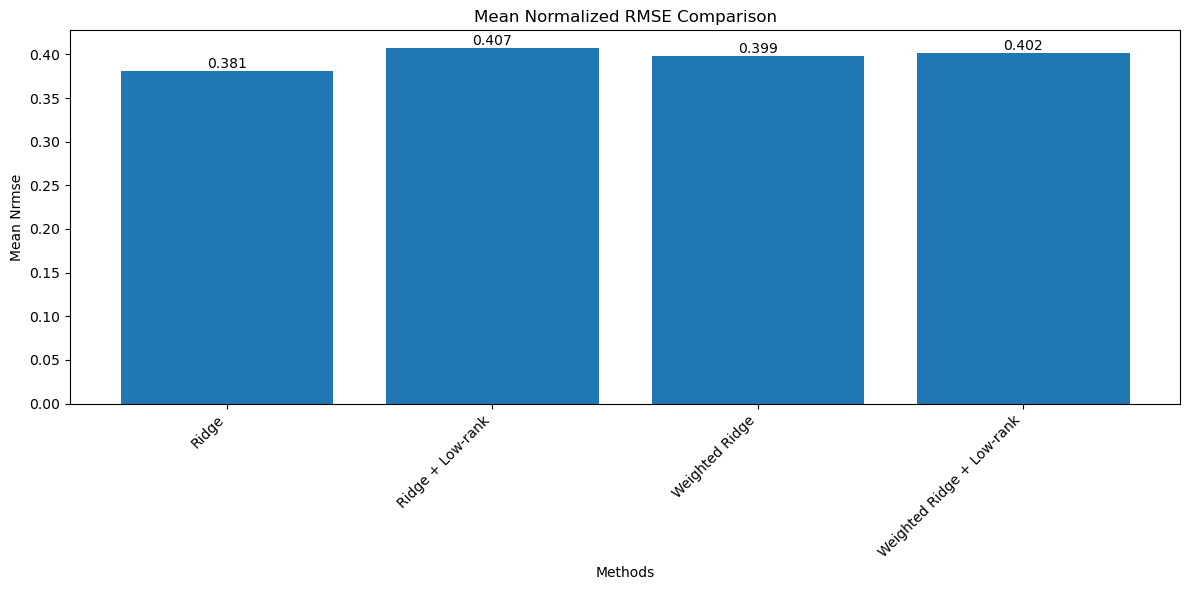

In [100]:
# Initialize visualizer
visualizer = ForceSMIPVisualizer(longitude, latitude, test_models)

# Plot performance comparison
fig = evaluator.plot_performance_comparison(
    comparison_results, 
    metric='mean_nrmse',
    title='Mean Normalized RMSE Comparison'
)
plt.show()

In [101]:
# reshape the trends for visualization
trends_ridge_fullmap = np.zeros((trends_ridge.shape[0], latitude.shape[0]*longitude.shape[0]), dtype=np.float32)
trends_ridge_fullmap[:,notnan_idx] = trends_ridge
trends_ridge_fullmap[:,nan_idx] = np.nan  # Fill NaNs for visualization

trends_weighted_lr_fullmap = np.zeros((trends_weighted_lr.shape[0], latitude.shape[0]*longitude.shape[0]), dtype=np.float32)
trends_weighted_lr_fullmap[:,notnan_idx] = trends_weighted_lr
trends_weighted_lr_fullmap[:,nan_idx] = np.nan  # Fill NaNs for visualization


trends_ground_truth_fullmap = trends_ground_truth
# trends_ground_truth_fullmap[:,notnan_idx] = trends_ground_truth
# trends_ground_truth_fullmap[:,nan_idx] = np.nan  # Fill NaNs for visualization

# Plot trends for the best method


Using vmin=-0.1, vmax=0.1 for colorbar


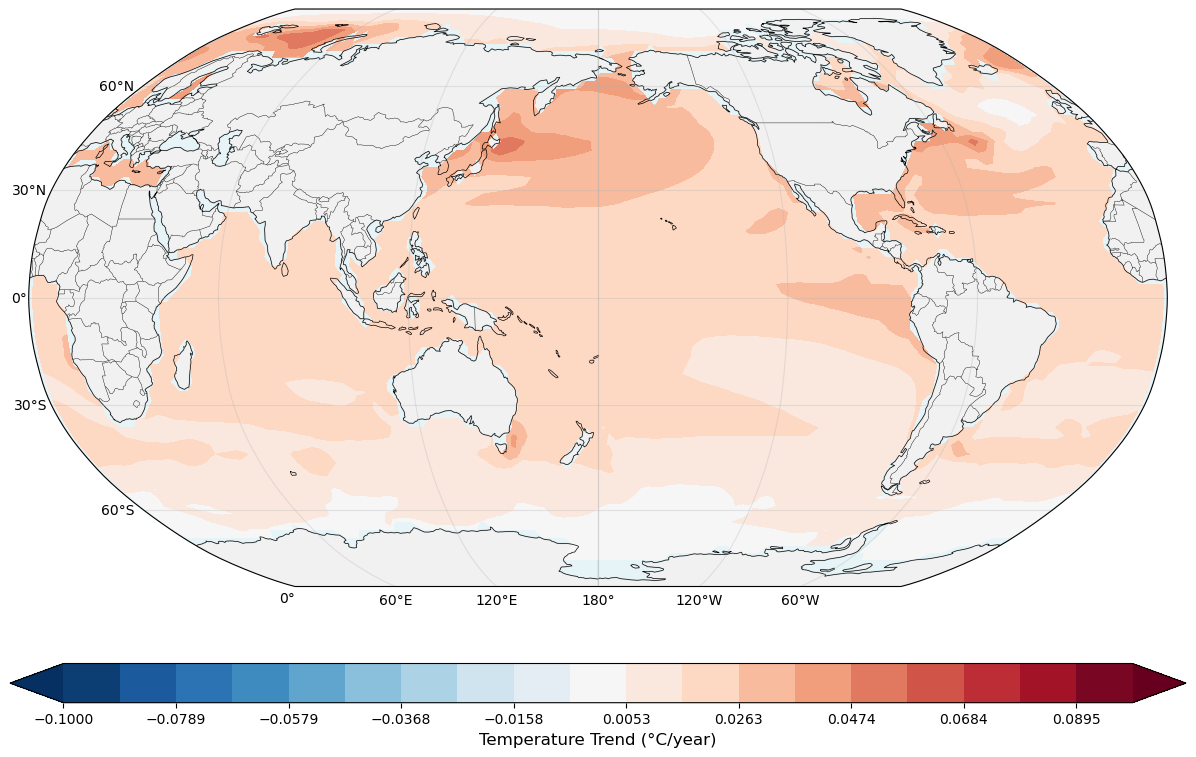

In [102]:
fig = visualizer.plot_robinson_projection(trends_ridge_fullmap, 
                                title="Global Temperature Trend",
                                cmap='RdBu_r', 
                                vmin=-0.1, 
                                vmax=0.1,
                                run_idx=0, 
                                central_longitude = 180)

Using vmin=-0.05, vmax=0.05 for colorbar


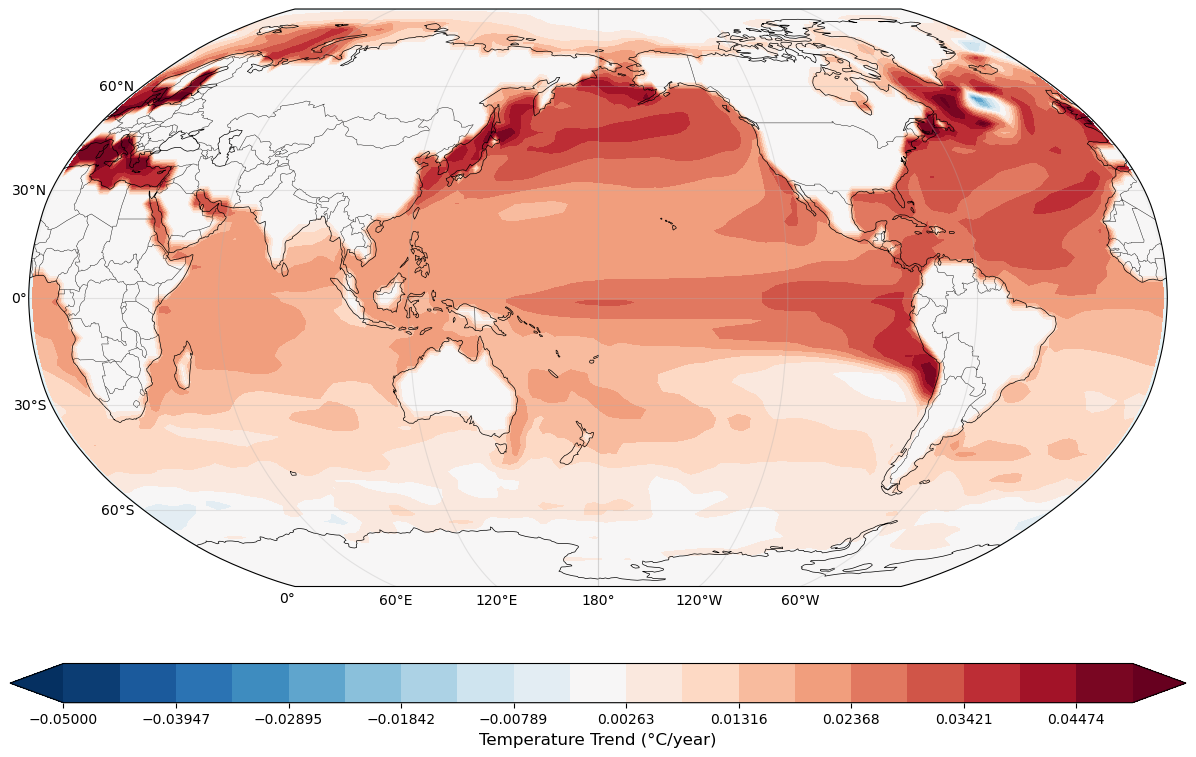

Using vmin=-0.05, vmax=0.05 for colorbar


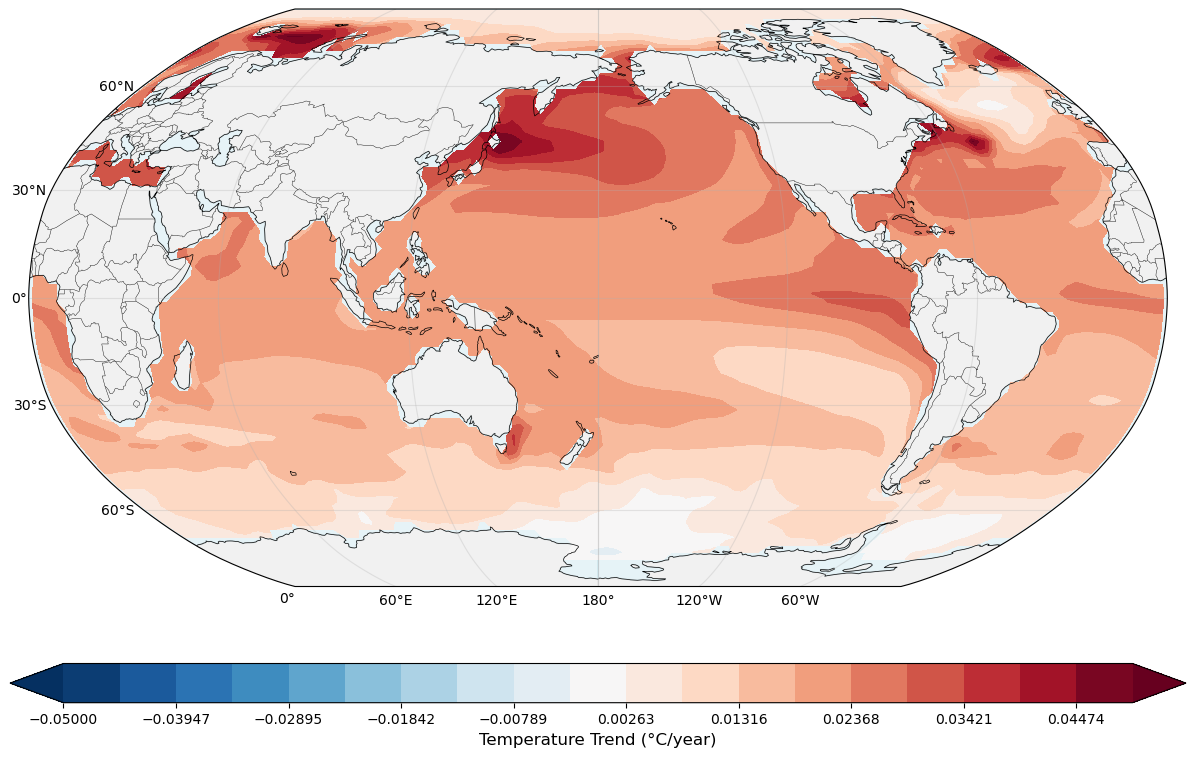

In [103]:
# Plot global trend maps for first test case
run_idx = 0  # First test model

# Ground truth
fig1 = visualizer.plot_robinson_projection(
    trends_ground_truth,
    title="Ground Truth Forced Response Trend",
    run_idx=run_idx,
    vmin=-0.05, vmax=0.05
)
plt.show()

# Best prediction
fig2 = visualizer.plot_robinson_projection(
    trends_weighted_lr_fullmap,
    title="Weighted Ridge + Low-rank Prediction",
    run_idx=run_idx,
    vmin=-0.05, vmax=0.05
)
plt.show()

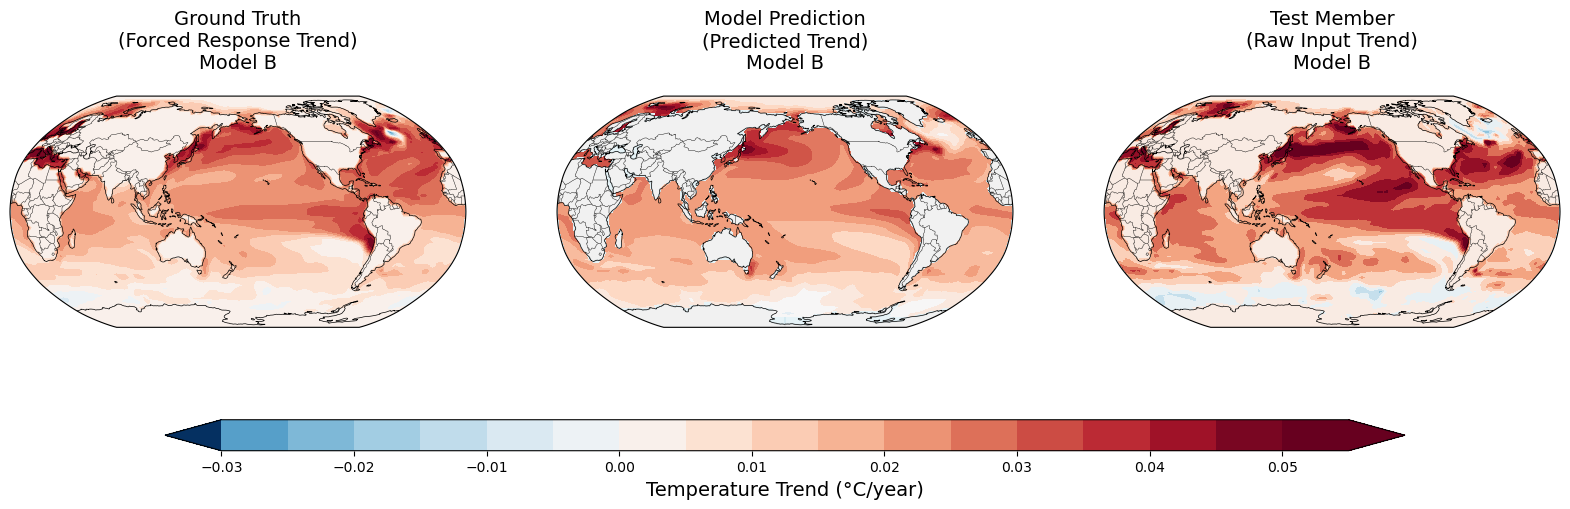

In [104]:
# Triple comparison plot
trend_test_member = compute_trends_from_data(data_test_yearly.reshape(
    data_test_yearly.shape[0],
    data_test_yearly.shape[1],
    -1
), trend_years)

fig3 = visualizer.plot_triple_comparison(
    trends_ground_truth_fullmap,
    trends_weighted_lr_fullmap,
    trend_test_member,
    run_idx=run_idx,
    vmin=-0.05, vmax=0.05
)
plt.show()

## 5. Comparison with ForceSMIP Estimates

In [105]:
# Load and evaluate ForceSMIP benchmark estimates
print("Evaluating ForceSMIP benchmark estimates...")

# Compute yearly averages for estimates
estimates_yearly = np.zeros((data_estimates.shape[0], data_estimates.shape[1],
                           data_estimates.shape[2] // 12,
                           data_estimates.shape[3], data_estimates.shape[4]), dtype=np.float32)

for idx_m in range(data_estimates.shape[0]):
    estimates_yearly[idx_m] = yearly_average(data_estimates[idx_m])

# Compute trends for estimates
trends_estimates = {}
for idx_m in range(estimates_yearly.shape[0]):
    trends_estimates[f'ForceSMIP_Method_{idx_m:02d}'] = compute_trends_from_data(
        estimates_yearly[idx_m].reshape(estimates_yearly[idx_m].shape[0],
                                          estimates_yearly[idx_m].shape[1],
                                          -1)[:,:,notnan_idx], trend_years
    )
print(f"Loaded {len(trends_estimates)} ForceSMIP benchmark methods")

Evaluating ForceSMIP benchmark estimates...


/home/vcohen/.conda/envs/cope/lib/python3.9/site-packages/numpy/core/_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


Loaded 30 ForceSMIP benchmark methods


In [106]:
# Compare our methods with ForceSMIP benchmarks
all_methods = {**predictions_dict, **trends_estimates}
full_comparison = evaluator.compare_methods(all_methods, trends_ground_truth[:, notnan_idx])

# Sort by performance
sorted_methods = sorted(full_comparison.items(), key=lambda x: x[1]['mean_nrmse'])

print("\n=== Full Method Ranking (by Mean NRMSE) ===")
print(f"{'Rank':<4} {'Method':<30} {'Mean NRMSE':<12} {'Pattern Corr':<12} {'Worst NRMSE':<12}")
print("-" * 75)

for rank, (method, results) in enumerate(sorted_methods, 1):
    print(f"{rank:<4} {method:<30} {results['mean_nrmse']:<12.4f} {results['mean_pattern_corr']:<12.4f} {results['worst_nrmse']:<12.4f}")

# Highlight our methods
our_methods = ['Ridge', 'Ridge + Low-rank', 'Weighted Ridge', 'Weighted Ridge + Low-rank']
print("\n=== Our Methods Performance ===")
for method in our_methods:
    rank = next(i for i, (m, _) in enumerate(sorted_methods, 1) if m == method)
    print(f"{method}: Rank {rank}/{len(sorted_methods)}")


=== Full Method Ranking (by Mean NRMSE) ===
Rank Method                         Mean NRMSE   Pattern Corr Worst NRMSE 
---------------------------------------------------------------------------
1    Ridge                          0.3812       0.9416       0.4780      
2    Weighted Ridge                 0.3987       0.9297       0.5226      
3    ForceSMIP_Method_29            0.4002       0.9405       0.5308      
4    Weighted Ridge + Low-rank      0.4018       0.9282       0.5271      
5    ForceSMIP_Method_05            0.4062       0.9303       0.5588      
6    Ridge + Low-rank               0.4072       0.9303       0.5107      
7    ForceSMIP_Method_08            0.4279       0.9218       0.5511      
8    ForceSMIP_Method_14            0.4352       0.9191       0.5527      
9    ForceSMIP_Method_04            0.4459       0.9193       0.5496      
10   ForceSMIP_Method_09            0.4603       0.9330       0.7204      
11   ForceSMIP_Method_18            0.4630       0.932

## 6. Parameter Sensitivity Analysis

In [107]:
# build the training set as the concatenation of all models except the one being validated and reshape for ridge regression
x_fold_train = np.concatenate([x_train_dict[k] for j, k in enumerate(x_train_dict.keys()) if j != 1], axis=0)
x_fold_train = x_fold_train.reshape(-1, x_fold_train.shape[-1])

y_fold_train = np.concatenate([y_train_dict[k] for j, k in enumerate(y_train_dict.keys()) if j != 1], axis=0)
y_fold_train = y_fold_train.reshape(-1, y_fold_train.shape[-1])

In [108]:
def cross_validation_lambda_optimization(x_train_dict, y_train_dict, lambda_values=None, 
                                       cv_folds=5, objective='worst_case', 
                                       verbose=True, random_state=42):
    """
    Perform cross-validation to optimize lambda with respect to worst-case objective.
    
    Args:
        x_train: Training input data (n_samples, n_features)
        y_train: Training target data (n_samples, n_targets)
        lambda_values: List of lambda values to test
        cv_folds: Number of cross-validation folds
        objective: Optimization objective ('worst_case', 'mean', 'variance')
        verbose: Whether to print progress
        random_state: Random seed for reproducibility
        
    Returns:
        Dictionary with optimization results
    """
    import numpy as np
    from sklearn.model_selection import KFold
    
    if lambda_values is None:
        lambda_values = [0.1, 1.0, 10.0, 100.0, 500.0, 1000.0, 2500.0, 5000.0, 10000.0]
    
    np.random.seed(random_state)

    # we do leave one out validation on the training set    
    cv_results = {}
    
    if verbose:
        print(f"Cross-validation with {cv_folds} folds for {len(lambda_values)} lambda values...")
        print(f"Optimization objective: {objective}")
    
    errors_mean = np.zeros(len(lambda_values), dtype=np.float32)
    errors_q75 = np.zeros(len(lambda_values), dtype=np.float32)
    errors_q90 = np.zeros(len(lambda_values), dtype=np.float32)
    errors_q95 = np.zeros(len(lambda_values), dtype=np.float32)
    errors_worst = np.zeros(len(lambda_values), dtype=np.float32) 

    for idx_lambda, lambda_reg in enumerate(lambda_values):

        if verbose:
            print(f"  Testing λ = {lambda_reg}")


        fold_mean_trend_nrmse = np.zeros(len(x_train_dict.keys()), dtype=np.float32)
        fold_q75_trend_nrmse = np.zeros(len(x_train_dict.keys()), dtype=np.float32)
        fold_q90_trend_nrmse = np.zeros(len(x_train_dict.keys()), dtype=np.float32)
        fold_q95_trend_nrmse = np.zeros(len(x_train_dict.keys()), dtype=np.float32)
        fold_worst_trend_nrmse = np.zeros(len(x_train_dict.keys()), dtype=np.float32)

        for idx_m, m in enumerate(x_train_dict.keys()):

            # build the training set as the concatenation of all models except the one being validated
            x_fold_train = np.concatenate([x_train_dict[k] for j, k in enumerate(x_train_dict.keys()) if j != idx_m], axis=0)
            x_fold_train = torch.from_numpy(x_fold_train.reshape(-1, x_fold_train.shape[-1]))
            y_fold_train = np.concatenate([y_train_dict[k] for j, k in enumerate(y_train_dict.keys()) if j != idx_m], axis=0)
            y_fold_train = torch.from_numpy(y_fold_train.reshape(-1, y_fold_train.shape[-1]))

            # build the test set
            x_fold_test = x_train_dict[m]
            y_fold_test = y_train_dict[m]

            # Train model
            w_fold = ridge_regression(x_fold_train, y_fold_train, lambda_reg, verbose=False)
            
            # Predict on validation set
            y_pred_fold = x_fold_test @ w_fold
            
            # compute the trend for each sample
            trend_pred = np.zeros((y_pred_fold.shape[0], y_pred_fold.shape[2]))
            trends_ground_truth = np.zeros((y_pred_fold.shape[0], y_pred_fold.shape[2]))
            for j in range(y_pred_fold.shape[0]):
                trend_pred[j,:] = np.polyfit(np.arange(y_pred_fold.shape[1]), y_pred_fold[j,:,:], 1)[0]
                trends_ground_truth[j,:] = np.polyfit(np.arange(y_fold_test.shape[1]), y_fold_test[j,:,:], 1)[0]


            # compute the normalized RMSE of the trend

            nmrse = np.sqrt(np.nansum((trend_pred - trends_ground_truth)**2,axis=1))/np.sqrt(np.nansum(trends_ground_truth**2, axis=1))


            fold_mean_trend_nrmse[idx_m] = np.mean(nmrse)
            fold_q75_trend_nrmse[idx_m] = np.nanpercentile(nmrse, 75)
            fold_q90_trend_nrmse[idx_m] = np.nanpercentile(nmrse, 90)
            fold_q95_trend_nrmse[idx_m] = np.nanpercentile(nmrse, 95)
            fold_worst_trend_nrmse[idx_m] = np.nanmax(nmrse)



        # Aggregate results only for the MEAN over runs
        errors_mean[idx_lambda] = np.mean(fold_mean_trend_nrmse) 
        errors_q75[idx_lambda] = np.nanpercentile(fold_mean_trend_nrmse, 75)
        errors_q90[idx_lambda] = np.nanpercentile(fold_mean_trend_nrmse, 90)
        errors_q95[idx_lambda] = np.nanpercentile(fold_mean_trend_nrmse, 95)
        errors_worst[idx_lambda] = np.max(fold_mean_trend_nrmse)  # Shape: (n_folds, n_spatial_locations)



        cv_results[lambda_reg] = {
            'mean_nrmse': errors_mean[idx_lambda],
            'q75_nrmse': errors_q75[idx_lambda],
            'q90_nrmse': errors_q90[idx_lambda],
            'q95_nrmse': errors_q95[idx_lambda],
            'worst_nrmse': errors_worst[idx_lambda],
            'nrmse_variance': np.nanvar(fold_mean_trend_nrmse)
        }
        
        if verbose:
            print(f"    Mean NRMSE: {cv_results[lambda_reg]['mean_nrmse']:.4f}")
            print(f"   Q75 NRMSE: {cv_results[lambda_reg]['q75_nrmse']:.4f}")
            print(f"   Q90 NRMSE: {cv_results[lambda_reg]['q90_nrmse']:.4f}")
            print(f"   Q95 NRMSE: {cv_results[lambda_reg]['q95_nrmse']:.4f}")
            print(f"    Worst NRMSE: {cv_results[lambda_reg]['worst_nrmse']:.4f}")
            print(f"    NRMSE Variance: {cv_results[lambda_reg]['nrmse_variance']:.4f}")
    
    # Select best lambda based on objective
    if objective == 'worst_case':
        best_lambda = min(cv_results.keys(), key=lambda x: cv_results[x]['worst_nrmse'])
        optimization_metric = 'worst_nrmse'
    elif objective == 'mean':
        best_lambda = min(cv_results.keys(), key=lambda x: cv_results[x]['mean_nrmse'])
        optimization_metric = 'mean_nrmse'
    elif objective == 'variance':
        best_lambda = min(cv_results.keys(), key=lambda x: cv_results[x]['nrmse_variance'])
        optimization_metric = 'nrmse_variance'
    else:
        raise ValueError(f"Unknown objective: {objective}")
    
    if verbose:
        print(f"\nOptimization complete!")
        print(f"Best λ = {best_lambda} (optimizing {optimization_metric})")
        print(f"Best {optimization_metric}: {cv_results[best_lambda][optimization_metric]:.4f}")
    
    return {
        'best_lambda': best_lambda,
        'optimization_metric': optimization_metric,
        'cv_results': cv_results,
        'lambda_values': lambda_values,
        'cv_folds': cv_folds,
        'objective': objective
    }

In [109]:
def cross_validation_lambda_rank_optimization(x_train_dict, y_train_dict, lambda_values=None, rank_values=None,
                                       cv_folds=5, objective='worst_case', 
                                       verbose=True, random_state=42):
    """
    Perform cross-validation to optimize lambda with respect to worst-case objective.
    
    Args:
        x_train: Training input data (n_samples, n_features)
        y_train: Training target data (n_samples, n_targets)
        lambda_values: List of lambda values to test
        cv_folds: Number of cross-validation folds
        objective: Optimization objective ('worst_case', 'mean', 'variance')
        verbose: Whether to print progress
        random_state: Random seed for reproducibility
        
    Returns:
        Dictionary with optimization results
    """
    import numpy as np
    from sklearn.model_selection import KFold
    
    if lambda_values is None:
        lambda_values = [0.1, 1.0, 10.0, 100.0, 500.0, 1000.0, 2500.0, 5000.0, 10000.0]

    if rank_values is None:
        rank_values = [5, 10, 15, 20, 25, 30, 50, 100]

    np.random.seed(random_state)

    # we do leave one out validation on the training set    
    cv_results = {}
    
    if verbose:
        print(f"Cross-validation with {cv_folds} folds for {len(lambda_values)} lambda values...")
        print(f"Optimization objective: {objective}")

    errors_mean = np.zeros((len(lambda_values), len(rank_values)), dtype=np.float32)
    errors_q75 = np.zeros((len(lambda_values), len(rank_values)), dtype=np.float32)
    errors_q90 = np.zeros((len(lambda_values), len(rank_values)), dtype=np.float32)
    errors_q95 = np.zeros((len(lambda_values), len(rank_values)), dtype=np.float32)
    errors_worst = np.zeros((len(lambda_values), len(rank_values)), dtype=np.float32)

    for idx_lambda, lambda_reg in enumerate(lambda_values):

        if verbose:
            print(f"  Testing λ = {lambda_reg}")


        fold_mean_trend_nrmse = np.zeros((len(rank_values), len(x_train_dict.keys())), dtype=np.float32)
        fold_q75_trend_nrmse = np.zeros((len(rank_values), len(x_train_dict.keys())), dtype=np.float32)
        fold_q90_trend_nrmse = np.zeros((len(rank_values), len(x_train_dict.keys())), dtype=np.float32)
        fold_q95_trend_nrmse = np.zeros((len(rank_values), len(x_train_dict.keys())), dtype=np.float32)
        fold_worst_trend_nrmse = np.zeros((len(rank_values), len(x_train_dict.keys())), dtype=np.float32)

        for idx_m, m in enumerate(x_train_dict.keys()):

            # build the training set as the concatenation of all models except the one being validated
            x_fold_train = np.concatenate([x_train_dict[k] for j, k in enumerate(x_train_dict.keys()) if j != idx_m], axis=0)
            x_fold_train = torch.from_numpy(x_fold_train.reshape(-1, x_fold_train.shape[-1]))
            y_fold_train = np.concatenate([y_train_dict[k] for j, k in enumerate(y_train_dict.keys()) if j != idx_m], axis=0)
            y_fold_train = torch.from_numpy(y_fold_train.reshape(-1, y_fold_train.shape[-1]))

            # build the test set
            x_fold_test = x_train_dict[m]
            y_fold_test = y_train_dict[m]

            # Train model
            w_fold = ridge_regression(x_fold_train, y_fold_train, lambda_reg, verbose=False)

            # Setup low-rank solver for efficient multiple rank solutions
            print(f"\nSetting up low-rank solver...")
            lr_solver = LowRankSolver()
            lr_solver.fit(x_fold_train, y_fold_train, w_fold, verbose=True)

            # Get solutions for multiple ranks efficiently
            rank_solutions = lr_solver.get_multiple_ranks(rank_values, verbose=True)

            nrmse = np.zeros((len(rank_solutions), x_fold_test.shape[0]), dtype=np.float32)

            # Predict on validation set
            for idx_r, (r, w) in enumerate(rank_solutions.items()):
                y_pred_fold = x_fold_test @ w

                # compute the trend for each sample
                trend_pred = np.zeros((y_pred_fold.shape[0], y_pred_fold.shape[2]))
                trends_ground_truth = np.zeros((y_pred_fold.shape[0], y_pred_fold.shape[2]))
                for j in range(y_pred_fold.shape[0]):
                    trend_pred[j,:] = np.polyfit(np.arange(y_pred_fold.shape[1]), y_pred_fold[j,:,:], 1)[0]
                    trends_ground_truth[j,:] = np.polyfit(np.arange(y_fold_test.shape[1]), y_fold_test[j,:,:], 1)[0]


                # compute the normalized RMSE of the trend
                nrmse[idx_r, :] = np.sqrt(np.nansum((trend_pred - trends_ground_truth)**2,axis=1))/np.sqrt(np.nansum(trends_ground_truth**2, axis=1))

            fold_mean_trend_nrmse[:,idx_m] = np.mean(nrmse,axis=1)
            fold_q75_trend_nrmse[:,idx_m] = np.nanpercentile(nrmse, 75, axis=1)
            fold_q90_trend_nrmse[:,idx_m] = np.nanpercentile(nrmse, 90, axis=1)
            fold_q95_trend_nrmse[:,idx_m] = np.nanpercentile(nrmse, 95, axis=1)
            fold_worst_trend_nrmse[:,idx_m] = np.nanmax(nrmse, axis=1)



        # Aggregate results only for the MEAN over runs
        errors_mean[idx_lambda,:] = np.mean(fold_mean_trend_nrmse, axis=1)
        errors_q75[idx_lambda,:] = np.nanpercentile(fold_mean_trend_nrmse, 75, axis=1)
        errors_q90[idx_lambda,:] = np.nanpercentile(fold_mean_trend_nrmse, 90, axis=1)
        errors_q95[idx_lambda,:] = np.nanpercentile(fold_mean_trend_nrmse, 95, axis=1)
        errors_worst[idx_lambda,:] = np.max(fold_mean_trend_nrmse, axis=1)  # Shape: (n_folds, n_spatial_locations)

        

        for idx_r, r in enumerate(rank_values):
            cv_results[lambda_reg, r] = {
                'mean_nrmse': errors_mean[idx_lambda, idx_r],
                'q75_nrmse': errors_q75[idx_lambda, idx_r],
                'q90_nrmse': errors_q90[idx_lambda, idx_r],
                'q95_nrmse': errors_q95[idx_lambda, idx_r],
                'worst_nrmse': errors_worst[idx_lambda, idx_r]
            }
        
            if verbose:
                print(f"    Mean NRMSE: {cv_results[lambda_reg, r]['mean_nrmse']:.4f}")
                print(f"   Q75 NRMSE: {cv_results[lambda_reg, r]['q75_nrmse']:.4f}")
                print(f"   Q90 NRMSE: {cv_results[lambda_reg, r]['q90_nrmse']:.4f}")
                print(f"   Q95 NRMSE: {cv_results[lambda_reg, r]['q95_nrmse']:.4f}")
                print(f"    Worst NRMSE: {cv_results[lambda_reg, r]['worst_nrmse']:.4f}")
                # print(f"    NRMSE Variance: {cv_results[lambda_reg, r]['nrmse_variance']:.4f}")
    
    # Select best lambda based on objective
    if objective == 'worst_case':
        (best_lambda,best_rank) = min(cv_results.keys(), key=lambda x: cv_results[x]['worst_nrmse'])
        optimization_metric = 'worst_nrmse'
    elif objective == 'mean':
        (best_lambda,best_rank) = min(cv_results.keys(), key=lambda x: cv_results[x]['mean_nrmse'])
        optimization_metric = 'mean_nrmse'
    else:
        raise ValueError(f"Unknown objective: {objective}")
    
    if verbose:
        print(f"\nOptimization complete!")
        print(f"Best λ = {best_lambda} (optimizing {optimization_metric})")
        print(f"Best {optimization_metric}: {cv_results[best_lambda, best_rank][optimization_metric]:.4f}")

    return {
        'best_lambda': best_lambda,
        'optimization_metric': optimization_metric,
        'cv_results': cv_results,
        'lambda_values': lambda_values,
        'rank_values': rank_values,
        'cv_folds': cv_folds,
        'objective': objective
    }

In [110]:
## 6.5 Cross-Validation Lambda Optimization

print("="*70)
print("         CROSS-VALIDATION LAMBDA OPTIMIZATION")
print("="*70)

# Import the cross-validation function
from algorithms import plot_cv_lambda_results

# Define lambda values to test (broader range for better optimization)
lambda_values_cv = [100.0, 500.0, 1000.0, 2500.0]
rank_values_cv = [5, 10, 15, 20, 25, 30, 50, 100]

print("Performing cross-validation to optimize lambda for worst-case performance...")

# Optimize lambda using cross-validation with worst-case objective
# cv_optimization = cross_validation_lambda_optimization(
#     x_train_dict_filtered, y_train_dict_filtered,
#     lambda_values=lambda_values_cv,
#     cv_folds=5,
#     objective='worst_case',  # Optimize for worst-case NRMSE
#     verbose=True
# )
cv_optimization = cross_validation_lambda_rank_optimization(
    x_train_dict_filtered, y_train_dict_filtered,
    lambda_values=lambda_values_cv,
    rank_values=rank_values_cv,
    cv_folds=5,
    objective='worst_case',  # Optimize for worst-case NRMSE
    verbose=True
)

# # Plot cross-validation results
# fig_cv = plot_cv_lambda_results(cv_optimization, figsize=(18, 5))
# plt.show()

# # Extract optimal lambda
# optimal_lambda_cv = cv_optimization['best_lambda']
# print(f"\n🎯 OPTIMAL LAMBDA (CV-optimized): {optimal_lambda_cv}")
# print(f"   Worst-case NRMSE: {cv_optimization['cv_results'][optimal_lambda_cv]['worst_nrmse']:.4f}")
# print(f"   Mean NRMSE: {cv_optimization['cv_results'][optimal_lambda_cv]['mean_nrmse']:.4f}")

         CROSS-VALIDATION LAMBDA OPTIMIZATION
Performing cross-validation to optimize lambda for worst-case performance...
Cross-validation with 5 folds for 4 lambda values...
Optimization objective: worst_case
  Testing λ = 100.0



Setting up low-rank solver...
Computing SVD for low-rank approximations...
SVD computed: U=torch.Size([36672, 6837]), S=torch.Size([6837]), Vt=torch.Size([6837, 6837])
Singular values range: 0.000002 to 2693.556396
Computed solutions for ranks: [5, 10, 15, 20, 25, 30, 50, 100]

Setting up low-rank solver...
Computing SVD for low-rank approximations...
SVD computed: U=torch.Size([42197, 6837]), S=torch.Size([6837]), Vt=torch.Size([6837, 6837])
Singular values range: 0.000002 to 2030.049072
Computed solutions for ranks: [5, 10, 15, 20, 25, 30, 50, 100]

Setting up low-rank solver...
Computing SVD for low-rank approximations...
SVD computed: U=torch.Size([41092, 6837]), S=torch.Size([6837]), Vt=torch.Size([6837, 6837])
Singular values range: 0.000002 to 2792.815918
Computed solutions for ranks: [5, 10, 15, 20, 25, 30, 50, 100]

Setting up low-rank solver...
Computing SVD for low-rank approximations...
SVD computed: U=torch.Size([36672, 6837]), S=torch.Size([6837]), Vt=torch.Size([6837, 6

In [111]:
A = cv_optimization['cv_results'][(100.0,5)]
A

{'mean_nrmse': 0.2618181,
 'q75_nrmse': 0.2480902,
 'q90_nrmse': 0.3188339,
 'q95_nrmse': 0.3424151,
 'worst_nrmse': 0.36599633}

In [112]:
def plot_cv_lambda_rank_results(cv_optimization_results, figsize=(15, 5)):
    """
    Plot cross-validation results for lambda optimization.
    
    Args:
        cv_optimization_results: Results from cross_validation_lambda_optimization
        figsize: Figure size tuple
        
    Returns:
        matplotlib figure
    """
    import matplotlib.pyplot as plt
    
    cv_results = cv_optimization_results['cv_results']
    best_lambda = cv_optimization_results['best_lambda']
    objective = cv_optimization_results['objective']
    
    lambdas_rank_values = list(cv_results.keys())
    lambdas = list(set([lambda_reg for (lambda_reg, _) in lambdas_rank_values]))
    rank_values = list(set([rank for (_, rank) in lambdas_rank_values]))



    mean_nrmse = np.zeros((len(lambdas), len(rank_values)), dtype=np.float32)
    worst_nrmse = np.zeros((len(lambdas), len(rank_values)), dtype=np.float32)

    

    for (i, l) in enumerate(lambdas):
        for (j, r) in enumerate(rank_values):
            mean_nrmse[i, j] = cv_results[(l, r)]['mean_nrmse']
            worst_nrmse[i, j] = cv_results[(l, r)]['worst_nrmse']

    # get the grid
    X, Y = np.meshgrid(lambdas, rank_values)
    print(X.shape)
    print(Y.shape)

    # plot the results as a colormap where x axis is the regularization parameter (λ) and y axis is the rank (r)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    c = ax1.pcolormesh(X, Y, mean_nrmse.T, shading='auto', cmap='viridis')
    fig.colorbar(c, ax=ax1, label='Mean NRMSE')
    ax1.set_title('Cross-Validation: Mean NRMSE')
    ax1.set_xlabel('Rank (r)')
    # ax1.set_xscale('log')
    ax1.set_ylabel('Regularization Parameter (λ)')
    ax1.set_yscale('log')
    ax1.set_xticks(rank_values)
    ax1.set_xticklabels(rank_values)
    ax1.grid(True, alpha=0.3)

    # Plot 2: Worst NRMSE
    c = ax2.pcolormesh(X, Y, worst_nrmse.T, shading='auto', cmap='viridis')
    fig.colorbar(c, ax=ax2, label='Worst NRMSE')
    ax2.set_title('Cross-Validation: Worst NRMSE')
    ax2.set_xlabel('Rank (r)')
    # ax2.set_xscale('log')
    ax2.set_ylabel('Regularization Parameter (λ)')
    ax2.set_yscale('log')
    ax2.set_xticks(rank_values)
    ax2.set_xticklabels(rank_values)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig      


In [113]:
def plot_cv_lambda_rank_results(cv_optimization_results, figsize=(15, 5)):
    """
    Plot cross-validation results for lambda optimization.

    Args:
        cv_optimization_results: Results from cross_validation_lambda_optimization
        figsize: Figure size tuple

    Returns:
        matplotlib figure
    """
    import matplotlib.pyplot as plt

    cv_results = cv_optimization_results['cv_results']
    best_lambda = cv_optimization_results['best_lambda']
    objective = cv_optimization_results['objective']

    lambdas_rank_values = list(cv_results.keys())
    lambdas = sorted(list(set([lambda_reg for (lambda_reg, _) in lambdas_rank_values])))
    rank_values = sorted(list(set([rank for (_, rank) in lambdas_rank_values])))

    mean_nrmse = np.zeros((len(lambdas), len(rank_values)), dtype=np.float32)
    worst_nrmse = np.zeros((len(lambdas), len(rank_values)), dtype=np.float32)

    for (i, l) in enumerate(lambdas):
        for (j, r) in enumerate(rank_values):
            mean_nrmse[i, j] = cv_results[(l, r)]['mean_nrmse']
            worst_nrmse[i, j] = cv_results[(l, r)]['worst_nrmse']

    X, Y = np.meshgrid(lambdas, rank_values)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # Use perceptually uniform colormaps
    cmap = "plasma"

    c1 = ax1.pcolormesh(X, Y, mean_nrmse.T, shading='auto', cmap=cmap, edgecolors='k', linewidth=0.2)
    fig.colorbar(c1, ax=ax1, label='Mean NRMSE')
    ax1.set_title('Cross-Validation: Mean NRMSE')
    ax1.set_xlabel('Lambda (λ)')
    ax1.set_ylabel('Rank (r)')
    ax1.set_yscale('log')
    ax1.set_xticks(lambdas)
    ax1.set_xticklabels([str(l) for l in lambdas])
    ax1.set_yticks(rank_values)
    ax1.set_yticklabels([str(r) for r in rank_values])
    ax1.grid(True, alpha=0.3)

    c2 = ax2.pcolormesh(X, Y, worst_nrmse.T, shading='auto', cmap=cmap, edgecolors='k', linewidth=0.2)
    fig.colorbar(c2, ax=ax2, label='Worst NRMSE')
    ax2.set_title('Cross-Validation: Worst NRMSE')
    ax2.set_xlabel('Lambda (λ)')
    ax2.set_ylabel('Rank (r)')
    ax2.set_yscale('log')
    ax2.set_xticks(lambdas)
    ax2.set_xticklabels([str(l) for l in lambdas])
    ax2.set_yticks(rank_values)
    ax2.set_yticklabels([str(r) for r in rank_values])
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

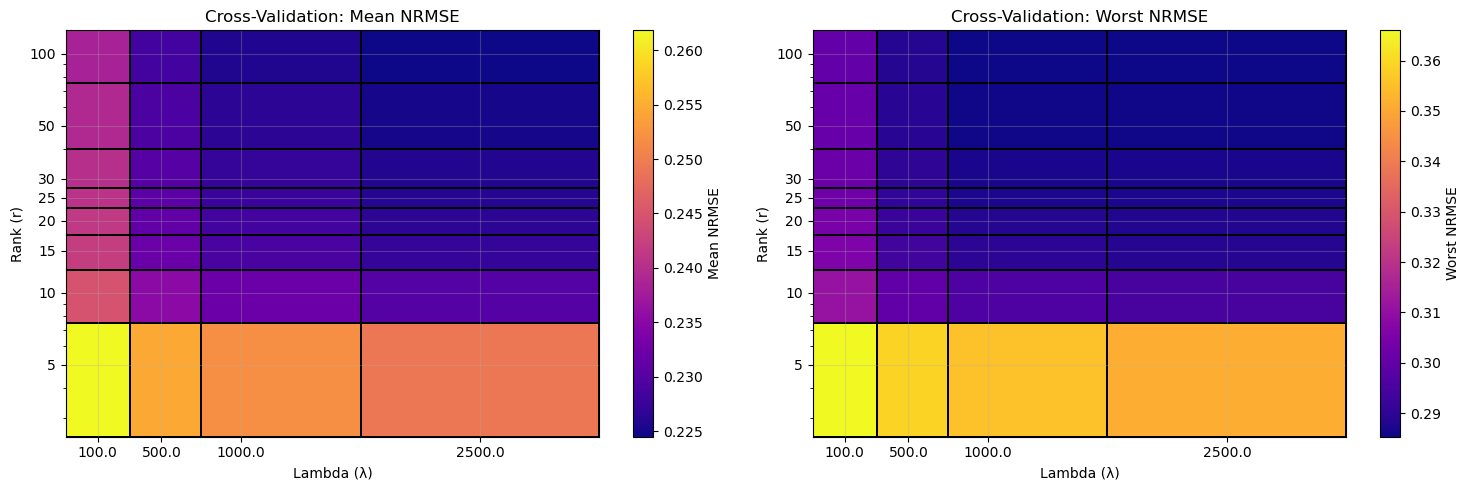

In [114]:
fig_tmp = plot_cv_lambda_rank_results(cv_optimization)

## 7. Summary and Conclusions

In [115]:
print("\n" + "="*60)
print("                 ANALYSIS SUMMARY")
print("="*60)

print(f"\nDataset: {variable.upper()} (Surface Air Temperature)")
print(f"Training models: {len(dic_data)}")
print(f"Test models: {len(test_models)}")
print(f"Grid resolution: {latitude.shape[0]} x {longitude.shape[0]}")
print(f"Trend period: Years {trend_years.start or 0} to {trend_years.stop or 'end'}")

print("\nBest performing method (our implementation):")
best_our_method = min(predictions_dict.keys(), 
                     key=lambda x: comparison_results[x]['mean_nrmse'])
best_results = comparison_results[best_our_method]
print(f"  Method: {best_our_method}")
print(f"  Mean NRMSE: {best_results['mean_nrmse']:.4f}")
print(f"  Mean Pattern Correlation: {best_results['mean_pattern_corr']:.4f}")
print(f"  Worst Case NRMSE: {best_results['worst_nrmse']:.4f}")

# Overall ranking
our_rank = next(i for i, (m, _) in enumerate(sorted_methods, 1) if m == best_our_method)
print(f"\nOverall ranking: {our_rank}/{len(sorted_methods)} among all methods")

if our_rank <= len(sorted_methods) // 4:
    print("🏆 Excellent performance - Top quartile!")
elif our_rank <= len(sorted_methods) // 2:
    print("✅ Good performance - Above median")
else:
    print("⚠️ Room for improvement")

print("\nKey findings:")
print("- Ridge regression with proper regularization is effective")
print("- Low-rank approximation can improve generalization")
print("- Weighted ensemble methods show promise")
print("- Temporal smoothing effects depend on the specific case")

print("\n" + "="*60)



                 ANALYSIS SUMMARY

Dataset: TOS (Surface Air Temperature)
Training models: 5
Test models: 5
Grid resolution: 72 x 144
Trend period: Years 30 to end

Best performing method (our implementation):
  Method: Ridge
  Mean NRMSE: 0.3812
  Mean Pattern Correlation: 0.9416
  Worst Case NRMSE: 0.4780

Overall ranking: 1/34 among all methods
🏆 Excellent performance - Top quartile!

Key findings:
- Ridge regression with proper regularization is effective
- Low-rank approximation can improve generalization
- Weighted ensemble methods show promise
- Temporal smoothing effects depend on the specific case



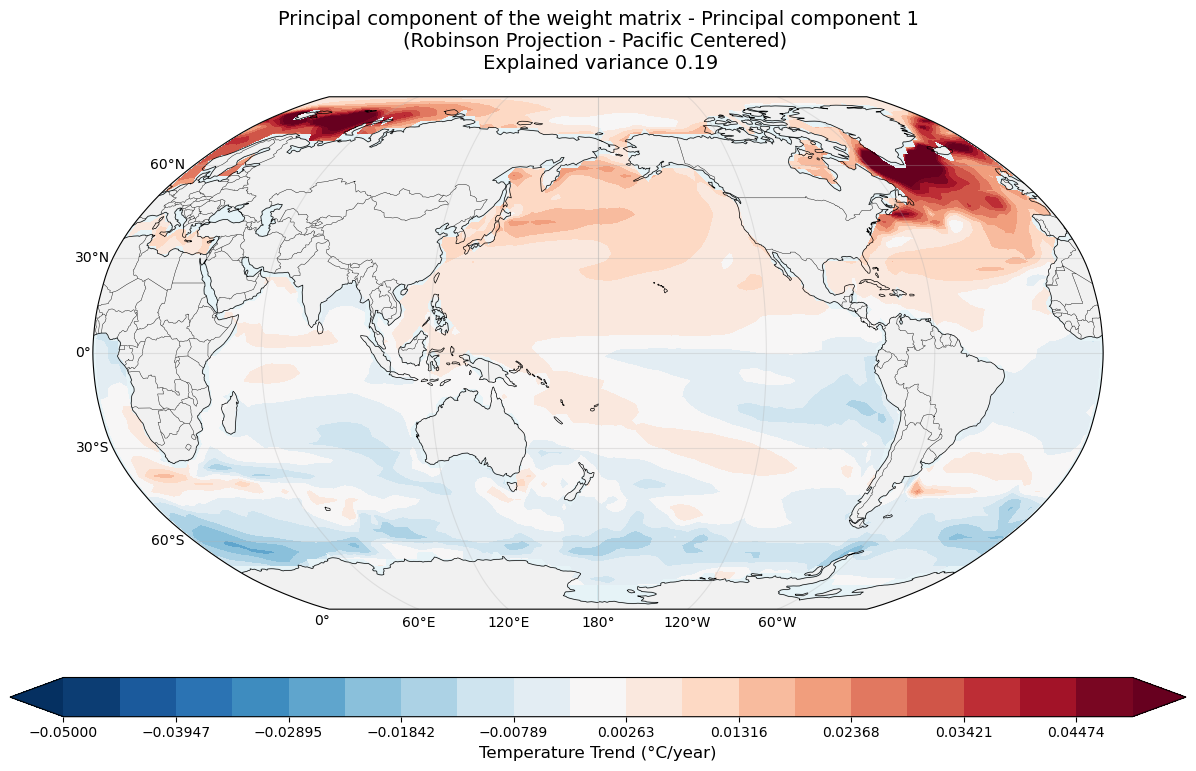

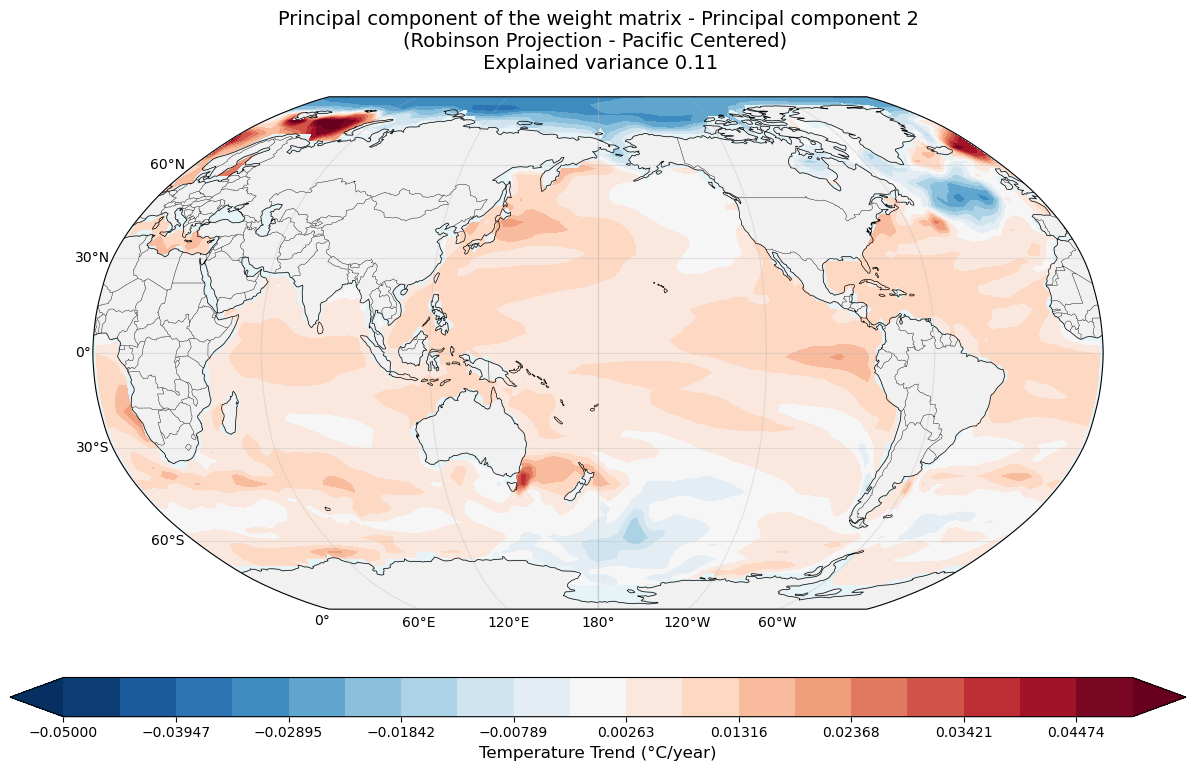

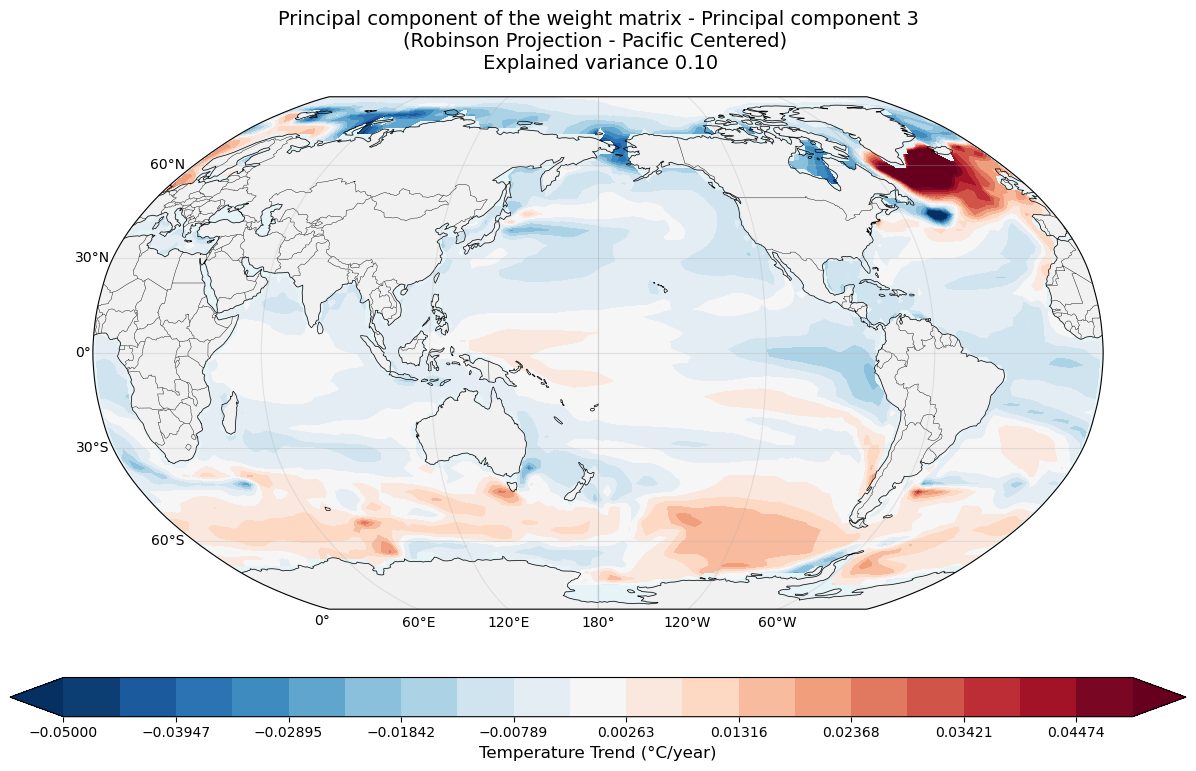

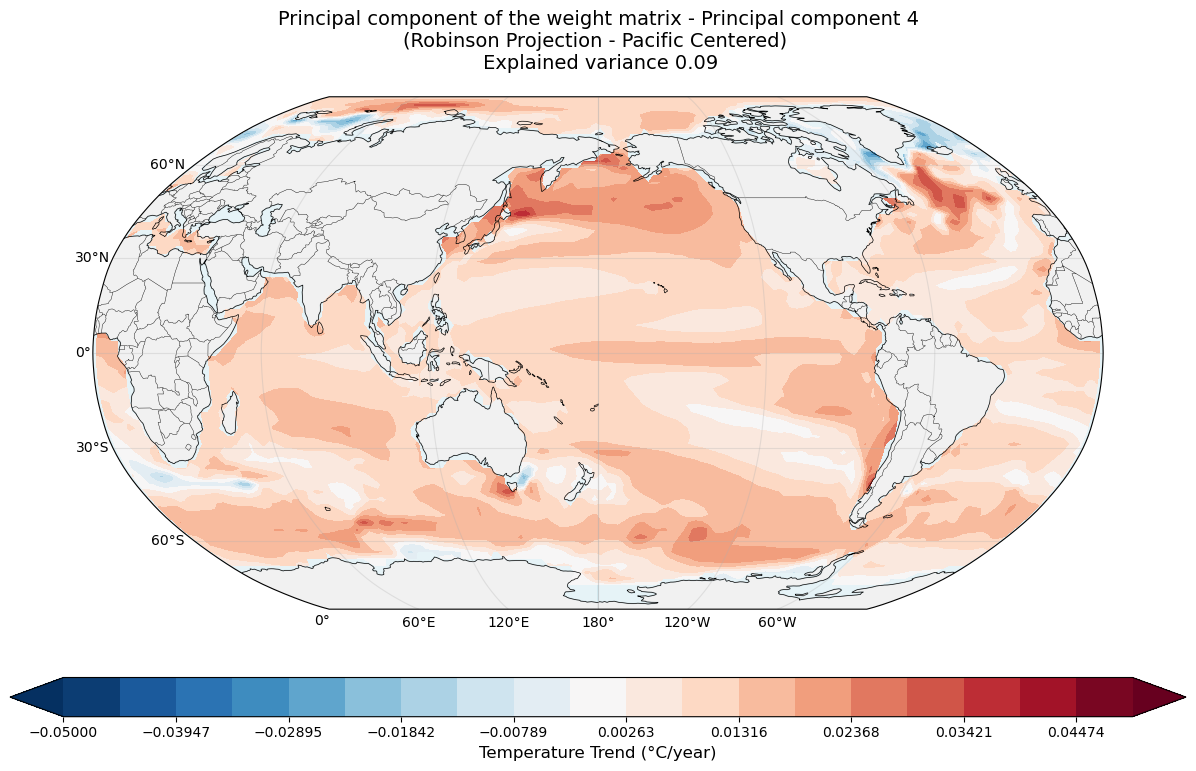

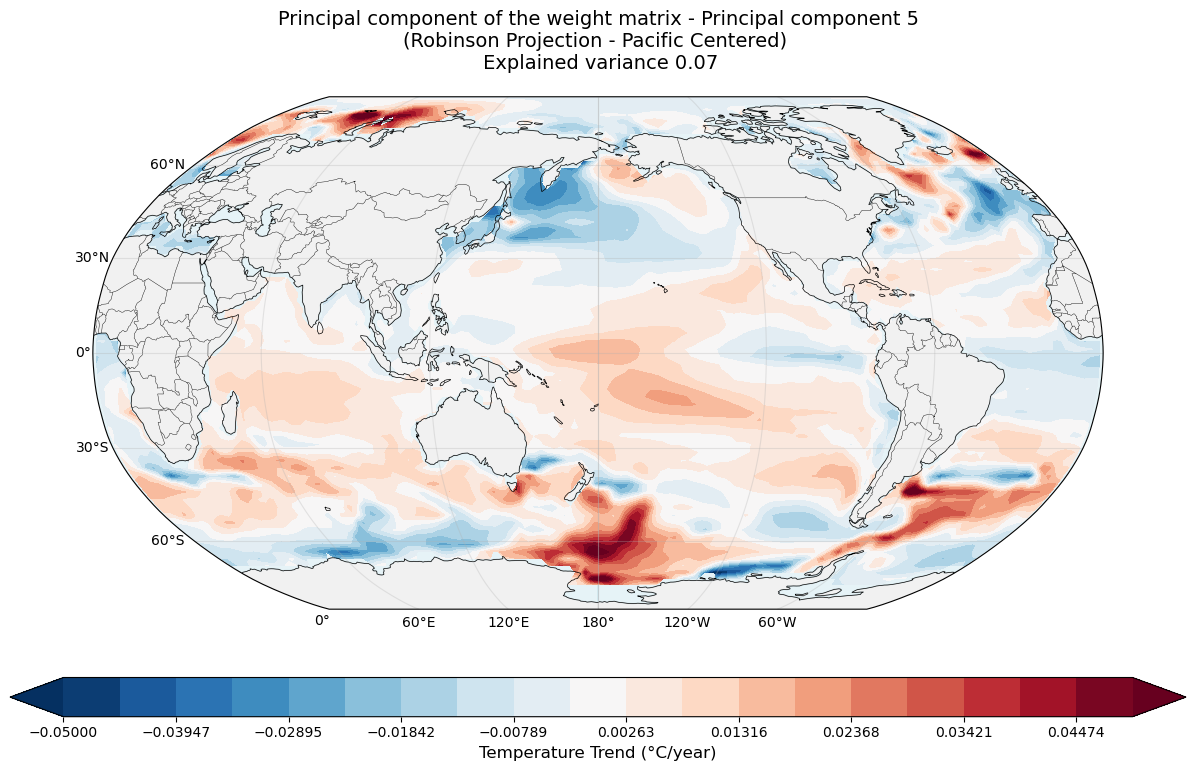

In [116]:
fig = visualizer.plot_principal_component(w_ridge, 
                                title = "Principal component of the weight matrix",
                                cmap = 'RdBu_r', 
                                vmin = -0.05, 
                                vmax = 0.05,
                                notnan_idx = notnan_idx,
                                nan_idx = nan_idx,
                                n_components = 5, 
                                central_longitude = 180)

Using vmin=-0.1, vmax=0.1 for colorbar
Using vmin=-0.1, vmax=0.1 for colorbar


ValueError: cannot reshape array of size 6837 into shape (72,144)

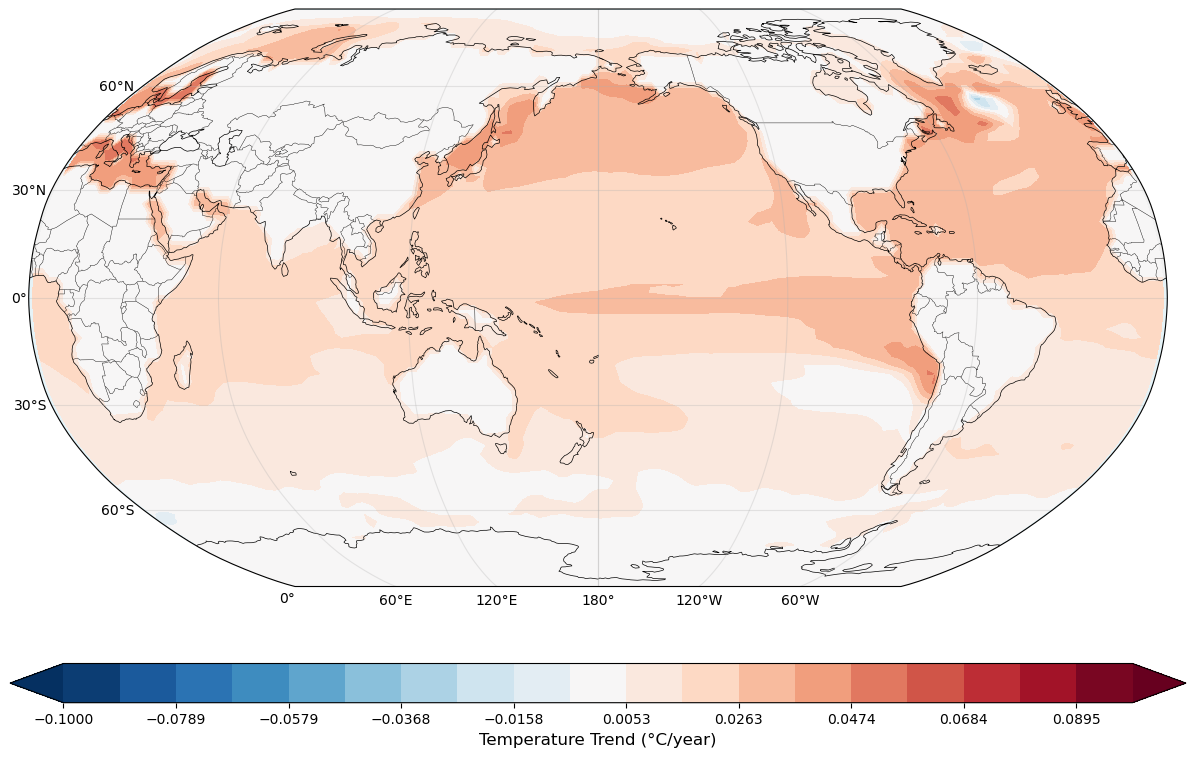

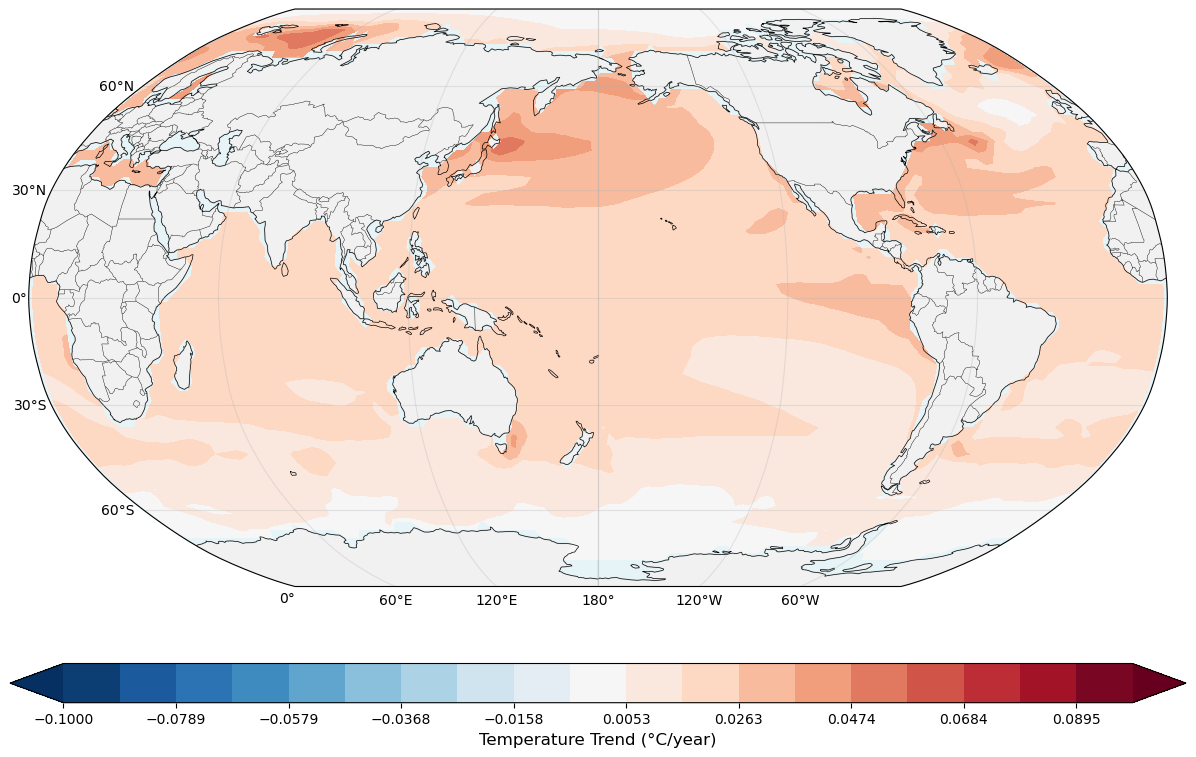

In [117]:
# display the trend pattern
fig = visualizer.plot_robinson_projection(trends_ground_truth, 
            title ="Global Temperature Trend",
            cmap = 'RdBu_r', 
            vmin= -0.1, 
            vmax = 0.1,
            run_idx = 0, 
            central_longitude = 180)                                

fig = visualizer.plot_robinson_projection(trends_ridge_fullmap, 
            title ="Global Temperature Trend",
            cmap = 'RdBu_r', 
            vmin= -0.1, 
            vmax = 0.1,
            run_idx = 0, 
            central_longitude = 180)

fig = visualizer.plot_robinson_projection(trends_ridge_lr, 
            title ="Global Temperature Trend",
            cmap = 'RdBu_r', 
            vmin= -0.1, 
            vmax = 0.1,
            run_idx = 0, 
            central_longitude = 180)

fig = visualizer.plot_robinson_projection(trends_estimates['ForceSMIP_Method_08'], 
            title ="Global Temperature Trend",
            cmap = 'RdBu_r', 
            vmin= -0.1, 
            vmax = 0.1,
            run_idx = 0, 
            central_longitude = 180)
